In [6]:
!pip install snowflake-connector-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 kB 4.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of pyopenssl to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 8.5 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3
  Attempting uninstall: pyOpenSSL
    Found e

In [10]:
import pandas as pd
import numpy as np

In [7]:
import snowflake.connector

In [8]:
from google.colab import userdata
username=userdata.get('username')
password=userdata.get('password')
account=userdata.get('account')
df.head()

NameError: name 'df' is not defined

In [11]:
con=snowflake.connector.connect(
    user=username,
    password=password,
    account=account,
    database='FIRSTDATABASE',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [12]:
query='select * from diabetes'

df=pd.read_sql(query, con)

print(df.head())

/tmp/ipykernel_10191/1363225065.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query, con)


   PREGNANCIES  GLUCOSE  BLOODPRESSURE  SKINTHICKNESS  INSULIN   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DIABETESPEDIGREEFUNCTION  AGE  OUTCOME  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [14]:
df.tail()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PREGNANCIES               768 non-null    int64  
 1   GLUCOSE                   768 non-null    int64  
 2   BLOODPRESSURE             768 non-null    int64  
 3   SKINTHICKNESS             768 non-null    int64  
 4   INSULIN                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DIABETESPEDIGREEFUNCTION  768 non-null    float64
 7   AGE                       768 non-null    int64  
 8   OUTCOME                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [16]:
df.describe()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [17]:
df.isnull().sum()

,0
PREGNANCIES,0
GLUCOSE,0
BLOODPRESSURE,0
SKINTHICKNESS,0
INSULIN,0
BMI,0
DIABETESPEDIGREEFUNCTION,0
AGE,0
OUTCOME,0


In [18]:
from sklearn.preprocessing import StandardScaler

In [19]:
sc=StandardScaler()
cols=df.columns.tolist()
for i in cols[:-1]:
  df[i]=sc.fit_transform(df[[i]])

In [20]:
df.head()

,PREGNANCIES,GLUCOSE,BLOODPRESSURE,SKINTHICKNESS,INSULIN,BMI,DIABETESPEDIGREEFUNCTION,AGE,OUTCOME
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1


In [21]:
def find_outlier(df):
  import math
  import numpy as np
  import seaborn as sns
  import matplotlib.pyplot as plt

  cols=df.columns.tolist()
  x=int(np.ceil(np.sqrt(len(cols[:-1]))))
  fig,ax = plt.subplots(x,x, figsize=(x*5, x*5))

  for i in range(len(cols[:-1])):
    plt.subplot(x,x,i+1)
    sns.boxplot(df[cols[i]])



In [22]:
q1=df['OUTCOME'].quantile(0.25)
q2=df['OUTCOME'].quantile(0.75)

iqr=q2-q1

outlier=df[(df['OUTCOME']<q1-iqr*0.15) | (df['OUTCOME']>q2+iqr*0.15)]

print(outlier.empty)

True


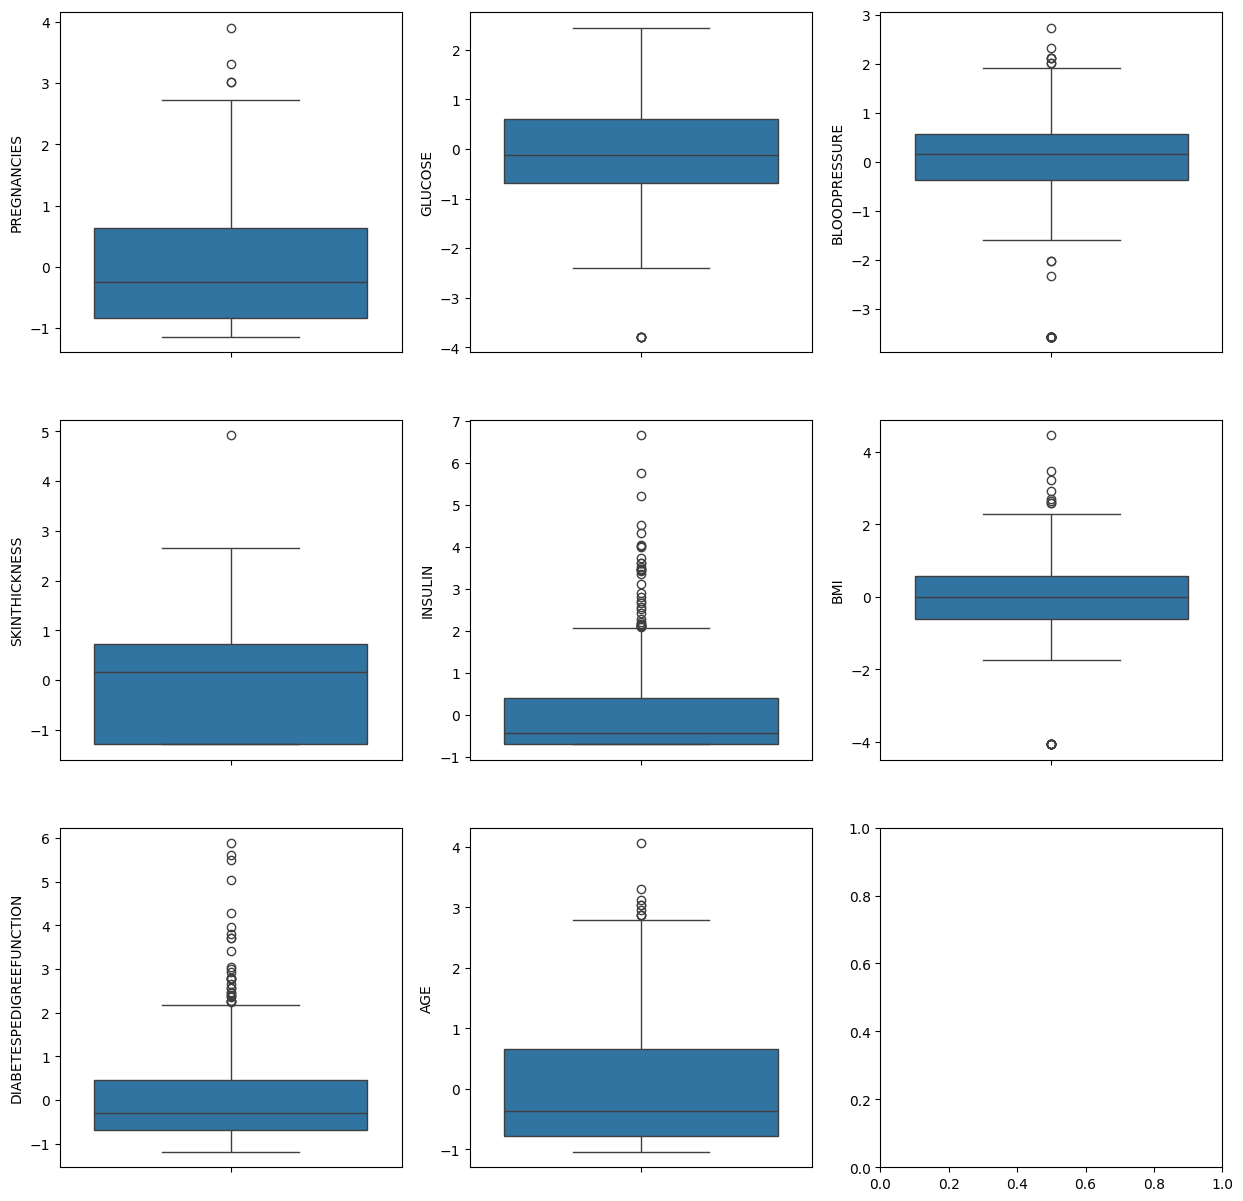

In [23]:
find_outlier(df)

In [25]:
test=pd.read_csv('/content/drive/MyDrive/MLT/Copy of survey lung cancer.csv')

In [26]:
test.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le=LabelEncoder()

for i in ['GENDER', 'LUNG_CANCER']:
  test[i]=le.fit_transform(test[i])

In [29]:
test.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


In [30]:
test.shape

(309, 16)

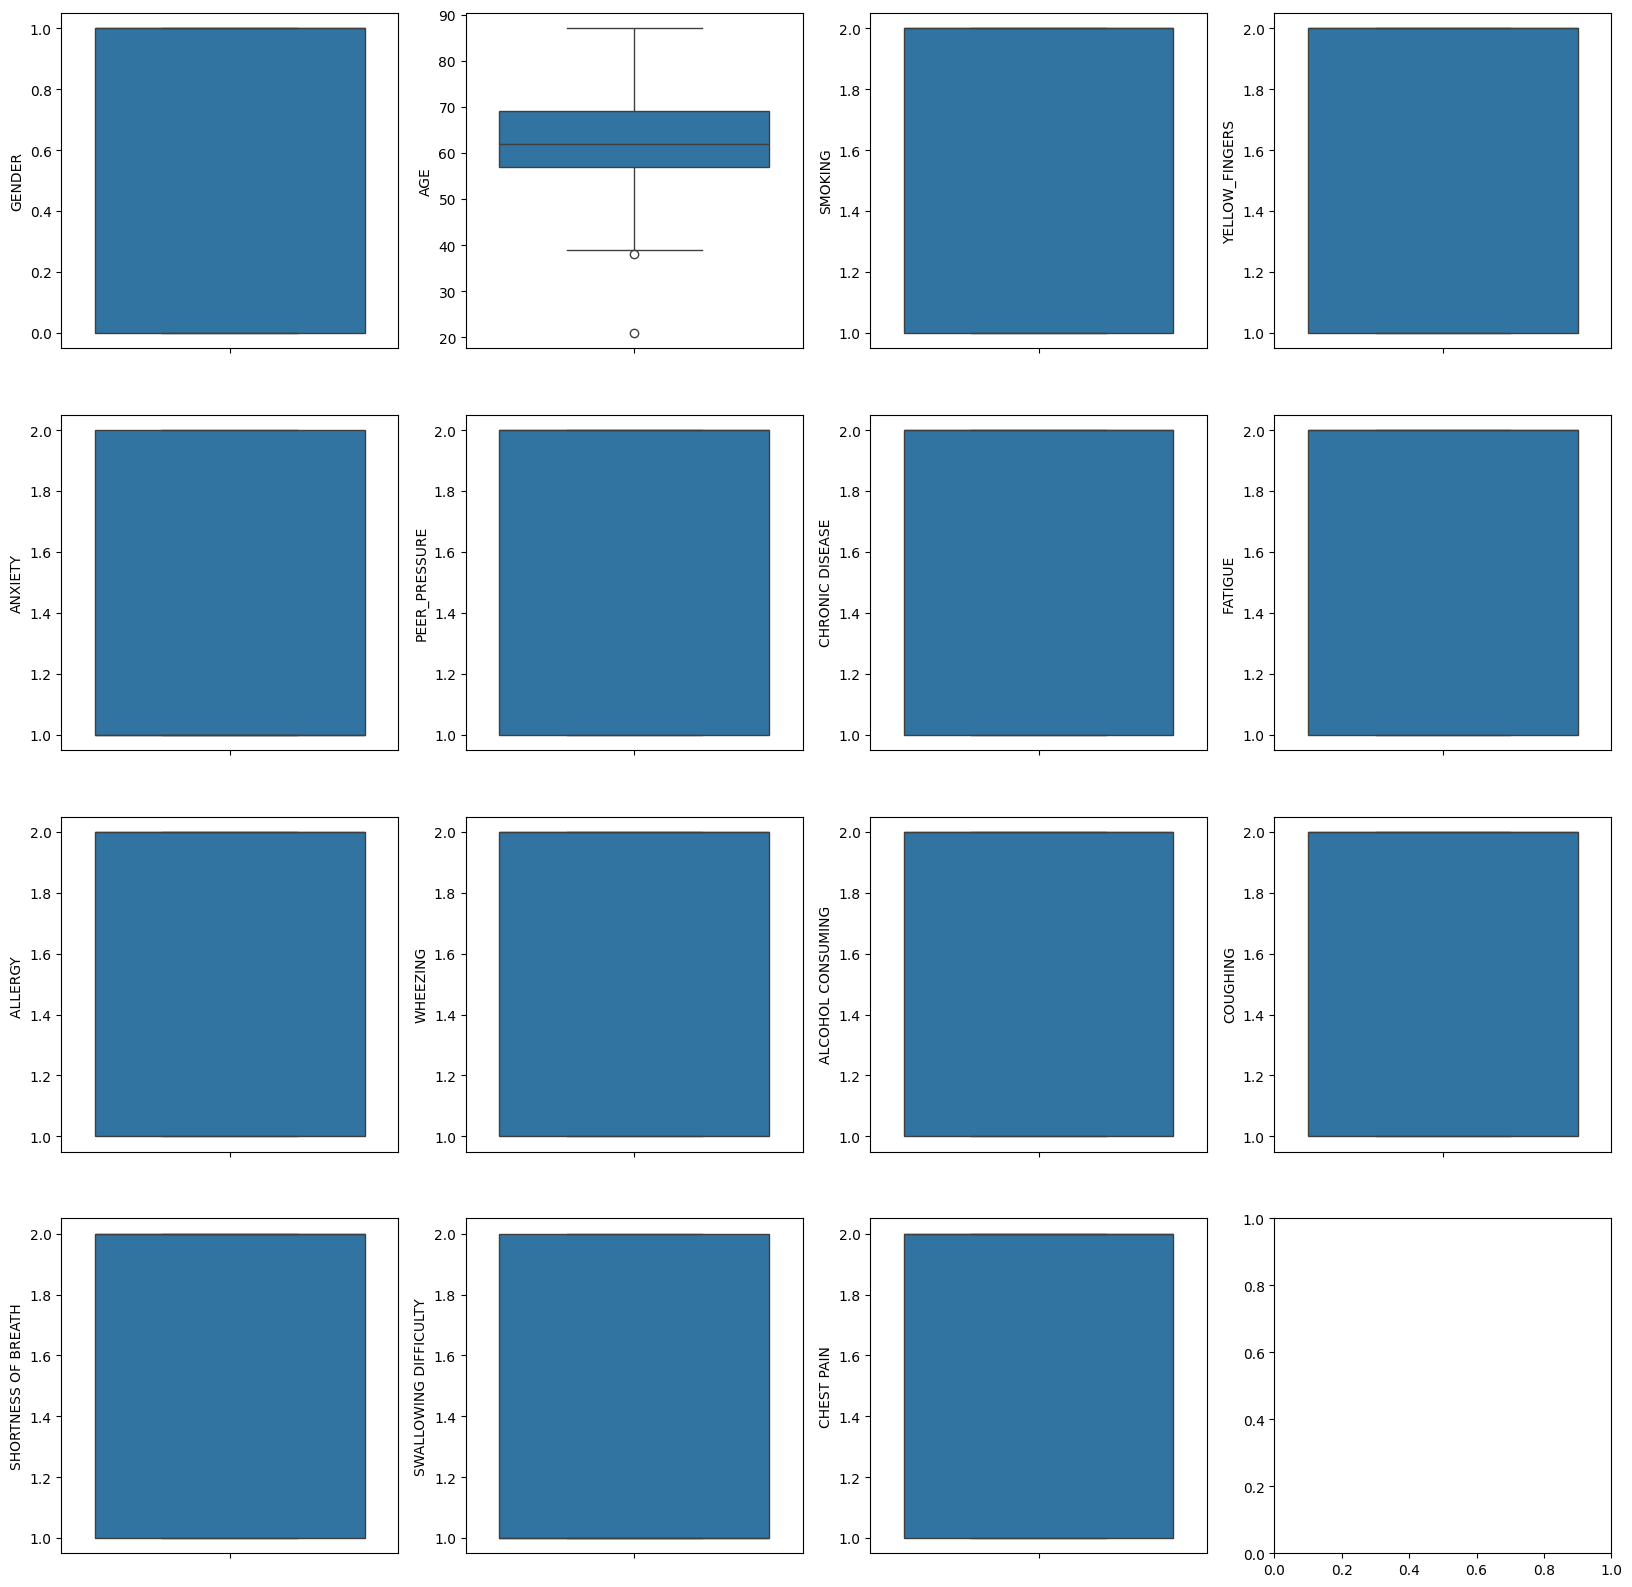

In [31]:
find_outlier(test)

In [32]:
def clear_outlier(df):
  !pip install scipy
  from scipy.stats.mstats import winsorize



In [33]:
def clear_outlier(df):
  import math
  import numpy as np
  import seaborn as sns

  cols=df.columns.tolist()
  x=int(np.ceil(np.sqrt(len(cols[:-1]))))
  fig,ax = plt.subplots(x,x, figsize=(x*5, x*5))

  for i in range(len(cols[:-1])):
    q1=df[i].quantile(0.25)
    q2=df[i].quantile(0.75)

    iqr=q2-q1

    outlier=df[(df[i]<q1-iqr*0.15) | (df[i]>q2+iqr*0.15)]

    if outlier.empty:
        !pip install scipy
        from scipy.stats.mstats import winsorize

        winsorized=winsorize(df[i], (0.1, 0.1))



In [34]:
x=df.drop('OUTCOME', axis=1)
y=df['OUTCOME']

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y)

In [36]:
from sklearn.tree import DecisionTreeClassifier

In [37]:
dc=DecisionTreeClassifier(max_depth=10, criterion='entropy')

In [38]:
model_dc=dc.fit(x_train, y_train)

In [39]:
y_pred=model_dc.predict(x_test)

In [40]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

print('accuracy_score')
print(accuracy_score(y_test, y_pred))
print()
'printconfusion_matrix'
print(confusion_matrix(y_test, y_pred))
print()
print('classification_report')
print(classification_report(y_test, y_pred))

accuracy_score
0.7447916666666666

[[101  26]
 [ 23  42]]

classification_report
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       127
           1       0.62      0.65      0.63        65

    accuracy                           0.74       192
   macro avg       0.72      0.72      0.72       192
weighted avg       0.75      0.74      0.75       192



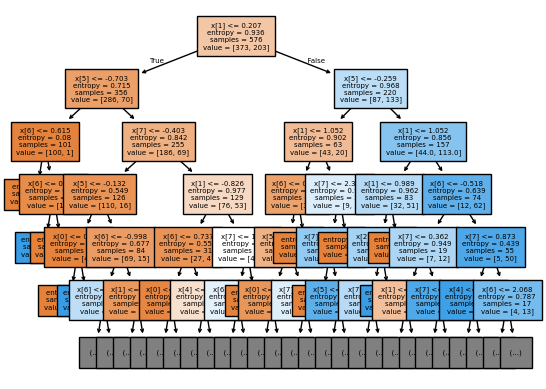

In [41]:
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(model_dc, filled=True, fontsize=5, max_depth=5)
plt.show(
)